# Comparing Methods for Chemical Space Coverage: A Focus on Generative Topographic Mapping (GTM)

In this notebook, we explore how different dimensionality reduction techniques visualize molecular datasets, with a specific focus on **Generative Topographic Mapping (GTM)**. Using data from the **OpenADMET ExpansionRx Blind Challenge**, we evaluate how effectively we can project high-dimensional chemical information into an interpretable 2D latent space.

### Why GTM?
While common methods like t-SNE and UMAP are excellent for clustering, GTM offers a unique **probabilistic framework**. By mapping data onto a predefined grid of nodes, GTM allows us to:
1. **Calculate Log-Likelihoods (LLH):** A rigorous way to measure how well a model "fits" the chemical space and identify structural outliers.
2. **Generate Density Maps:** Visualize the "applicability domain" by showing where the majority of training data resides.
3. **Analyze Data Shifts:** Objectively compare the distribution of training and test sets in a structured latent space.

### Workflow Overview
- **Setup:** Load and preprocess the OpenADMET dataset.
- **Fingerprint Projection:** Generate RDKit count fingerprints and compare t-SNE, UMAP, and GTM.
- **Descriptor Projection:** Project physical and chemical descriptors to gain a property-based perspective.
- **Density & Log-Likelihood Analysis:** Deep dive into GTM's probabilistic outputs to evaluate chemical space coverage.

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from openTSNE import TSNE
from umap import UMAP

import useful_rdkit_utils as uru
from gtm_utils import calc_gtm, plot_gtm_class_map

# Set visualization style
sns.set_theme(style="whitegrid", context="talk")
tqdm.pandas()

## 1. Setup and Data Ingestion

We load the training and test datasets from the OpenADMET ExpansionRx Blind Challenge. These sets are combined into a single dataframe to ensure consistent transformations across both groups.

In [2]:
BASE_URL = "hf://datasets/openadmet/openadmet-expansionrx-challenge-data/"
train_df = pd.read_csv(f"{BASE_URL}expansion_data_train.csv")
test_df = pd.read_csv(f"{BASE_URL}expansion_data_test.csv")

train_df['dataset'] = 'train'
test_df['dataset'] = 'test'

combo_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Total compounds: {len(combo_df)} (Train: {len(train_df)}, Test: {len(test_df)})")

Total compounds: 7608 (Train: 5326, Test: 2282)


## 2. Structural Space: Projecting Fingerprints 

We use **RDKit count fingerprints** to represent molecular structure. Due to their high dimensionality, we perform an initial PCA reduction to 50 dimensions (preserving the majority of variance) before applying t-SNE, UMAP, and GTM.

In [3]:
smi2fp = uru.Smi2Fp()
combo_df["fp"] = combo_df.SMILES.progress_apply(smi2fp.get_np_counts)

  0%|          | 0/7608 [00:00<?, ?it/s]

In [4]:
fp_matrix = np.stack(combo_df.fp)
fp_pca = PCA(n_components=50)
combo_df["fp_pcs"] = fp_pca.fit_transform(fp_matrix).tolist()

explained_var = np.sum(fp_pca.explained_variance_ratio_) * 100
print(f"Explained variance (50 PCs): {explained_var:.2f}%")

Explained variance (50 PCs): 69.93%


### Manifold Projections
We calculate 2D coordinates using t-SNE, UMAP, and GTM. Note that GTM also returns **responsibilities** (probabilistic node assignments) and **log-likelihoods** (model fit).

In [9]:
%%time
pcs_matrix = np.stack(combo_df.fp_pcs)

print("Calculating t-SNE...")
fp_tsne = TSNE(n_components=2, n_jobs=-1, learning_rate='auto')
combo_df[['fp_tsne_x', 'fp_tsne_y']] = fp_tsne.fit(pcs_matrix)

print("Calculating UMAP...")
fp_umap = UMAP(n_components=2, n_jobs=-1)
combo_df[['fp_umap_x', 'fp_umap_y']] = fp_umap.fit_transform(pcs_matrix)

print("Calculating GTM...")
fp_gtm_obj, fp_crd_df, fp_resps, fp_llhs = calc_gtm(pcs_matrix)
combo_df["fp_gtm_x"] = fp_crd_df.x
combo_df["fp_gtm_y"] = fp_crd_df.y
combo_df["fp_llh"] = fp_llhs

Calculating t-SNE...
Calculating UMAP...
Calculating GTM...


  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 43 s, sys: 5.82 s, total: 48.8 s
Wall time: 16.7 s


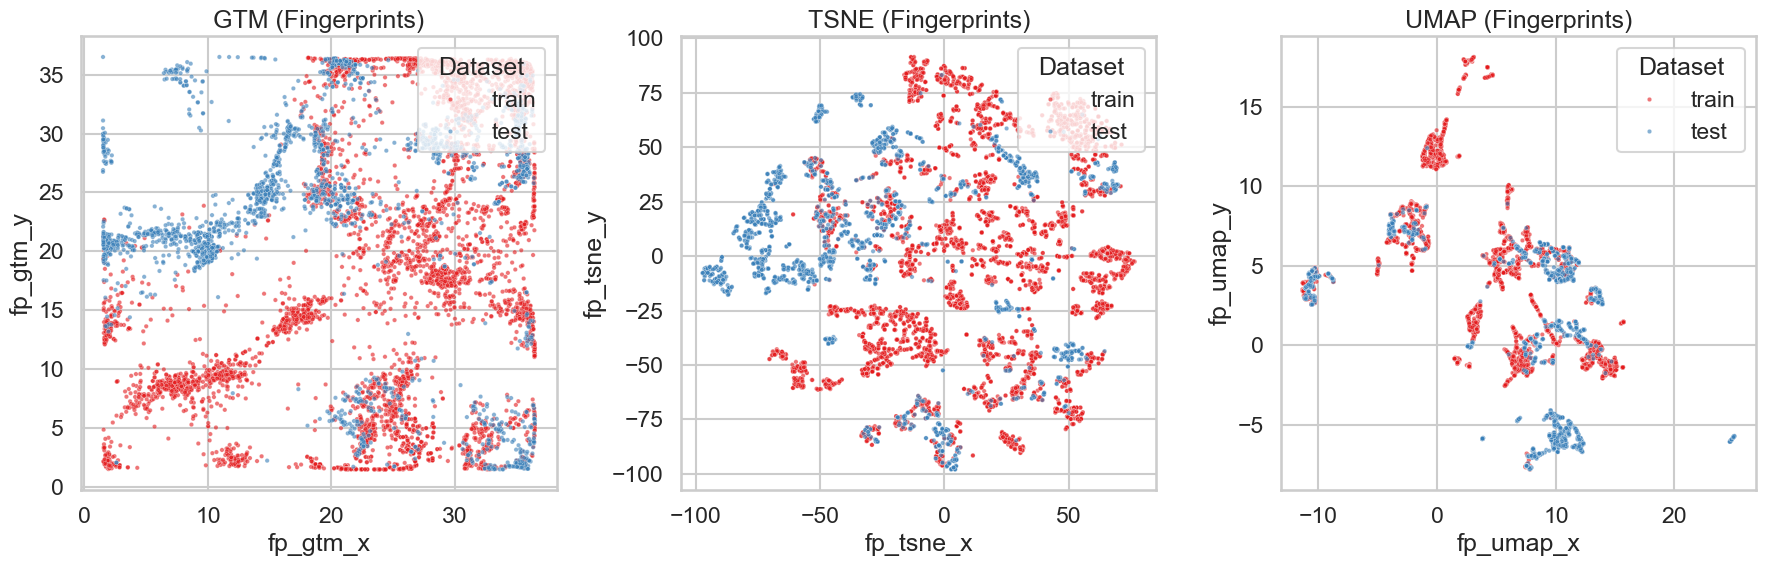

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
methods = ["gtm", "tsne", "umap"]

for i, method in enumerate(methods):
    sns.scatterplot(
        x=f"fp_{method}_x", y=f"fp_{method}_y", 
        hue="dataset", data=combo_df, 
        ax=axes[i], s=10, alpha=0.6, palette="Set1"
    )
    axes[i].set_title(f"{method.upper()} (Fingerprints)")
    axes[i].legend(title="Dataset", loc="upper right")

plt.tight_layout()
plt.show()

## 3. Property Space: Projecting RDKit Descriptors

While fingerprints capture structural connectivity, **RDKit descriptors** capture physical and chemical properties (e.g., LogP, Molecular Weight). We calculate a suite of descriptors, clean/scale them, and repeat the projections.

In [12]:
rdkit_desc = uru.RDKitDescriptors()
combo_df['desc'] = combo_df.SMILES.progress_apply(rdkit_desc.calc_smiles)

desc_matrix = np.stack(combo_df.desc)
desc_scaled, _ = uru.clean_and_scale_descriptors(desc_matrix)
print(f"Calculated and scaled {desc_scaled.shape[1]} descriptors.")

  0%|          | 0/7608 [00:00<?, ?it/s]

Calculated and scaled 217 descriptors.


In [14]:
%%time
print("Calculating t-SNE...")
tsne = TSNE(n_components=2, n_jobs=-1)
combo_df[['desc_tsne_x', 'desc_tsne_y']] = tsne.fit(desc_scaled)

print("Calculating UMAP...")
umap = UMAP(n_components=2, n_jobs=-1)
combo_df[['desc_umap_x', 'desc_umap_y']] = umap.fit_transform(desc_scaled)

print("Calculating GTM...")
desc_gtm_obj, desc_crd_df, desc_resps, desc_llhs = calc_gtm(desc_scaled)
combo_df['desc_gtm_x'] = desc_crd_df.x
combo_df['desc_gtm_y'] = desc_crd_df.y
combo_df['desc_llh'] = desc_llhs

Calculating t-SNE...
Calculating UMAP...
Calculating GTM...


  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 3min 9s, sys: 14.6 s, total: 3min 23s
Wall time: 36.1 s


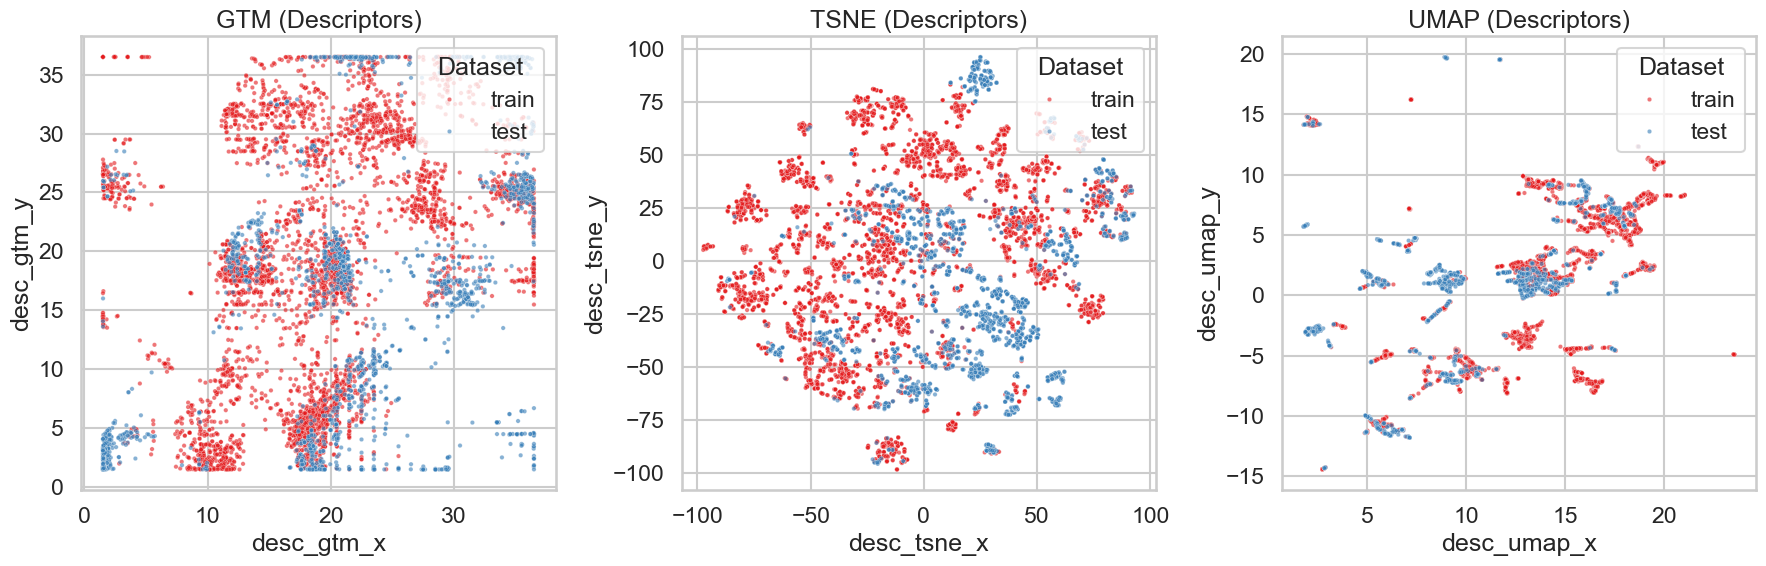

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, method in enumerate(methods):
    sns.scatterplot(
        x=f"desc_{method}_x", y=f"desc_{method}_y", 
        hue="dataset", data=combo_df, 
        ax=axes[i], s=10, alpha=0.6, palette="Set1"
    )
    axes[i].set_title(f"{method.upper()} (Descriptors)")
    axes[i].legend(title="Dataset", loc="upper right")

plt.tight_layout()
plt.show()

In [33]:
combo_df['is_test'] = combo_df.dataset == "test"

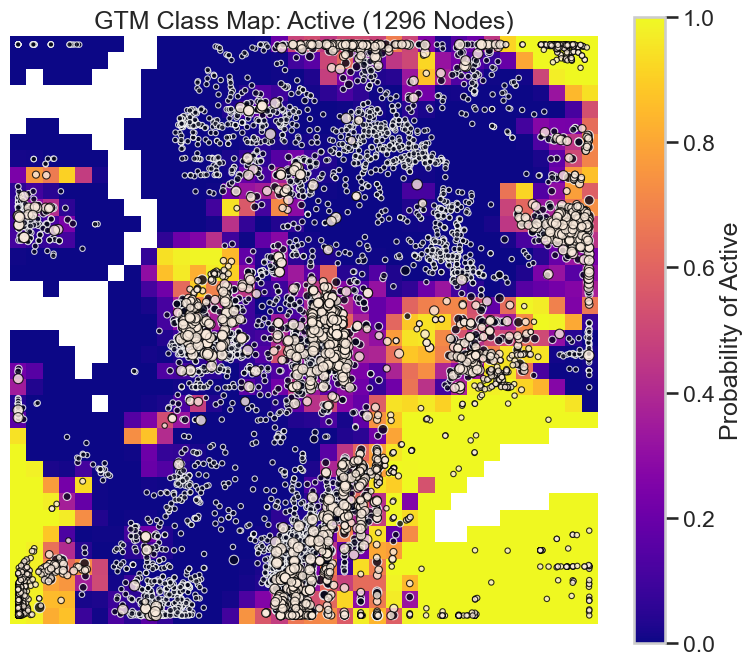

array([0.99897818, 0.99928151, 0.99943274, ..., 0.99826963, 0.99993717,
       0.99999489], shape=(1296,))

In [34]:
plot_gtm_class_map(desc_resps,desc_crd_df.values,combo_df.is_test)

## 4. Deep Dive: GTM Probabilistic Analysis

In this section, we leverage GTM's unique features to evaluate **chemical space coverage** and **applicability domains**.

### GTM Density Maps
A density map shows where the data points are concentrated in the latent space. By comparing the density of the training set versus the test set, we can visually identify if the test set falls into sparsely populated regions of the training manifold.

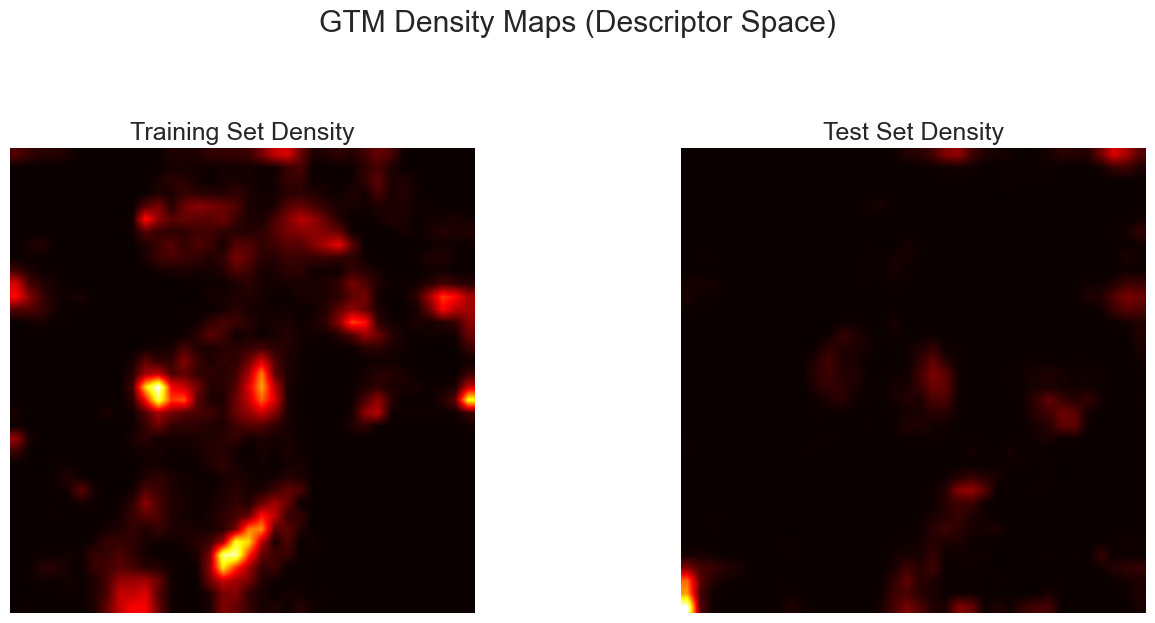

In [25]:
def plot_gtm_density(resp, title, ax):
    """Plots the mean responsibility density on the GTM grid."""
    n_nodes = resp.shape[1]
    grid_dim = int(np.sqrt(n_nodes))
    density = np.mean(resp, axis=0).reshape((grid_dim, grid_dim)).T
    im = ax.imshow(density, origin="lower", cmap="hot", interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
    return im

train_mask = combo_df.dataset == "train"
test_mask = combo_df.dataset == "test"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_gtm_density(desc_resps[train_mask], "Training Set Density", axes[0])
plot_gtm_density(desc_resps[test_mask], "Test Set Density", axes[1])
plt.suptitle("GTM Density Maps (Descriptor Space)", y=1.05)
plt.tight_layout()
plt.show()

### Log-Likelihood (LLH) and Applicability Domain
The Log-Likelihood measures how well the model represents each molecule. Molecules with very low LLH are likely **structural outliers** or belong to a region of chemical space not well-captured by the GTM manifold. This is an objective way to define the Applicability Domain (AD).

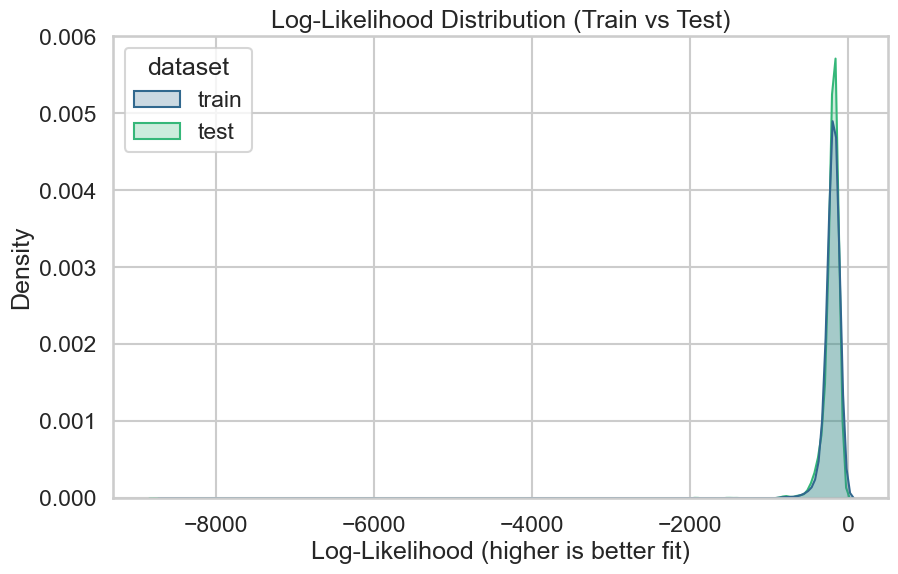

In [18]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=combo_df, x="desc_llh", hue="dataset", fill=True, common_norm=False, palette="viridis")
plt.title("Log-Likelihood Distribution (Train vs Test)")
plt.xlabel("Log-Likelihood (higher is better fit)")
plt.ylabel("Density")
plt.show()

### Identifying Outliers
We can look at molecules in the test set that have lower LLHs than the 5th percentile of the training set. these are molecules where predictions should be treated with caution.

In [19]:
train_llh_threshold = combo_df[train_mask]["desc_llh"].quantile(0.05)
outliers = combo_df[test_mask & (combo_df["desc_llh"] < train_llh_threshold)]

print(f"Training 5th percentile LLH: {train_llh_threshold:.2f}")
print(f"Number of test set outliers (outside AD): {len(outliers)} ({len(outliers)/len(test_df)*100:.1f}% of test set)")

Training 5th percentile LLH: -346.52
Number of test set outliers (outside AD): 183 (8.0% of test set)


## 5. Conclusions

- **t-SNE and UMAP** provide high-quality clusters but lack a formal probabilistic interpretation for the "space between clusters."
- **GTM** provides a structured, grid-based view of the data. Its density maps allow for an intuitive understanding of chemical space occupancy.
- **Log-Likelihood** serves as a powerful metric for the Applicability Domain, identifying exactly which compounds in a new dataset (test set) are structurally distinct from the training distribution.

By combining these methods, cheminformaticians can build a multi-faceted view of their data, ensuring that machine learning models are applied to molecules they can reasonably understand.